# 08. Where the model fails, what drives it, risk bands and expected loss

**Objective.** Find segments where the model is weaker or biased, identify what drives predictions (globally and for single applicants), define risk bands, and compute expected loss.

**Business question.** Who is the model wrong about, why does a given applicant score high, and how large is the portfolio's expected loss?

**Why this analysis is needed.** An accurate average hides local failures. An underwriter must also be able to say *why* an applicant is risky, and finance needs the loss in currency, not just a probability.

Scores are from the model fitted on the training split; analysis uses the **validation split**. The test split stays closed after Notebook 07.

**About explanations.** SHAP is not available in this build environment. Global importance uses **permutation importance** (drop in AUC when one column is shuffled). Single-applicant explanations use **occlusion**: replace one feature at a time with the training median (or most common category) and record the change in log-odds. This is simpler than SHAP, ignores feature interactions and correlation, and is labelled as such. See D30.

*Educational project. Not a lending policy.*

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import roc_auc_score
from src.data import load_modelling_table
from src.plots import apply_style
from src.explain import global_importance, local_attribution, reference_row
from src.risk import BAND_EDGES, assign_band, band_summary, expected_loss
from src.policy import ASSUMED_LGD
from src.train import *

warnings.filterwarnings("ignore")
apply_style()
table = load_modelling_table()
bundle = joblib.load(config.MODELS_DIR / "pd_model.joblib")
model, columns, cutoff = bundle["model"], bundle["columns"], bundle["threshold"]
valid = table[table["split"] == "valid"].copy()
valid["pd"] = model.predict_proba(valid[columns])[:, 1]
y = valid[config.TARGET]
print("validation AUC:", round(roc_auc_score(y, valid["pd"]), 4), " cutoff:", cutoff)

validation AUC: 0.7705  cutoff: 0.16


## Segment performance

For each group: size, actual default rate, average predicted probability, and AUC within the group. A good model has predicted close to actual in every group; a group with a much lower within-group AUC is one where ranking is weaker. Groups under 500 applicants are omitted, since their AUC is too noisy.

In [2]:
valid["AGE_BAND"] = pd.cut(valid["AGE_YEARS"], [20, 30, 40, 50, 60, 70], right=False).astype(str)
def segment_table(column):
    rows = []
    for value, group in valid.groupby(column, observed=True):
        if len(group) < 500 or group[config.TARGET].nunique() < 2:
            continue
        rows.append({"segment": f"{column}={value}", "n": len(group), "actual": group[config.TARGET].mean(),
                     "predicted": group["pd"].mean(), "auc": roc_auc_score(group[config.TARGET], group["pd"])})
    return pd.DataFrame(rows)
segments = pd.concat([segment_table(c) for c in ["AGE_BAND", "CODE_GENDER", "NAME_CONTRACT_TYPE", "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS"]], ignore_index=True)
segments["gap"] = segments["predicted"] - segments["actual"]
print(segments.round(4).to_string(index=False))

                                          segment     n  actual  predicted    auc     gap
                                AGE_BAND=[20, 30)  8972  0.1130     0.1190 0.7539  0.0060
                                AGE_BAND=[30, 40) 16485  0.0977     0.0933 0.7706 -0.0044
                                AGE_BAND=[40, 50) 15487  0.0754     0.0768 0.7646  0.0015
                                AGE_BAND=[50, 60) 13606  0.0615     0.0627 0.7627  0.0012
                                AGE_BAND=[60, 70)  6952  0.0483     0.0487 0.7275  0.0004
                                    CODE_GENDER=F 40529  0.0702     0.0713 0.7679  0.0011
                                    CODE_GENDER=M 20972  0.1011     0.1001 0.7633 -0.0010
                    NAME_CONTRACT_TYPE=Cash loans 55650  0.0834     0.0836 0.7697  0.0002
               NAME_CONTRACT_TYPE=Revolving loans  5852  0.0555     0.0571 0.7650  0.0016
            NAME_INCOME_TYPE=Commercial associate 14349  0.0760     0.0774 0.7627  0.0014
          

**Result.** Predicted and actual rates are within 0.6 points in almost every group. The exceptions: *Incomplete higher* education is over-predicted (8.77% vs 7.07%, n=2,065, gap 1.7 points, roughly three standard errors). Within-group AUC is lowest for *Lower secondary* education (0.697, n=757), age 60-70 (0.728), and *Separated* (0.737), against 0.7705 overall; it is highest for higher education (0.780).

**Interpretation.** Calibration holds across groups, so the model is not systematically over- or under-estimating for any large group. Ranking is weaker among the oldest applicants and some small groups. With 757 applicants in the smallest group, its AUC has a standard error of about 0.03, so that one is a lead rather than a finding. The over-prediction for incomplete-higher education is the only calibration gap that looks real.

**Decision.** No segment-specific models or adjustments: differences are small, and adding them would multiply complexity. The weaker groups are listed as limitations in the model card.

## Age and gender: does the model need them? (D19)

The model is refitted without `CODE_GENDER`, `DAYS_BIRTH` and `AGE_YEARS` and compared on validation.

In [3]:
without = [c for c in columns if c not in ("CODE_GENDER", "DAYS_BIRTH", "AGE_YEARS")]
scores, no_demo_pd = fit_and_score(make_boosting(table, without, max_depth=4, learning_rate=0.05), table, without)
print("with age and gender   AUC", round(roc_auc_score(y, valid["pd"]), 4))
print("without age and gender AUC", round(scores["roc_auc"], 4), " PR-AUC", round(scores["pr_auc"], 4), " Brier", round(scores["brier"], 4))
valid["pd_no_demo"] = no_demo_pd
for name, column in [("with", "pd"), ("without", "pd_no_demo")]:
    approved = valid[column] <= cutoff
    print(name, "approval rate by gender:", valid.assign(a=approved).groupby("CODE_GENDER")["a"].mean().round(3).to_dict())

with age and gender   AUC 0.7705
without age and gender AUC 0.768  PR-AUC 0.2465  Brier 0.0675
with approval rate by gender: {'F': 0.898, 'M': 0.811, 'XNA': 1.0}
without approval rate by gender: {'F': 0.89, 'M': 0.827, 'XNA': 1.0}


**Result.** Removing age and gender lowers validation AUC from 0.7705 to 0.7680 (PR-AUC 0.2465, Brier 0.0675 unchanged). The approval-rate gap between women and men at the 0.16 cutoff narrows from 8.7 points (89.8% vs 81.1%) to 6.3 points (89.0% vs 82.7%) but does not disappear.

**Interpretation.** The cost of excluding them is 0.0025 AUC, which is within noise for a single comparison. The gap remains because default rates genuinely differ (7.0% women, 10.1% men in validation) and other variables (occupation, organisation type, income type) are correlated with gender. Removing a column does not remove its information, so this test does not make the model 'fair'; it shows the model's dependence on the column. Age also has a strong monotone relationship with default (D19).

**Decision.** The evaluated model keeps age and gender, because it is the one frozen before the test split was opened and the accuracy cost of removal is negligible. In any real use they should be excluded or reviewed against the applicable regulation. The app does not ask for gender. This is recorded as a limitation, not resolved. See D31.

## What drives the model? Permutation importance

On 25,000 validation rows, one column at a time is shuffled and the fall in AUC is recorded (3 repeats). Correlated columns share importance, so a small number for one of a correlated pair understates its information.

                       auc_drop  spread
EXT_SOURCE_2             0.0374  0.0015
EXT_SOURCE_3             0.0319  0.0008
EXT_SOURCE_1             0.0159  0.0025
CREDIT_ANNUITY_RATIO     0.0130  0.0011
AMT_GOODS_PRICE          0.0095  0.0011
INST_LATE_SHARE          0.0054  0.0004
CODE_GENDER              0.0041  0.0005
ORGANIZATION_TYPE        0.0040  0.0007
BUREAU_DEBT_TO_CREDIT    0.0028  0.0004
OWN_CAR_AGE              0.0027  0.0007
AMT_CREDIT               0.0026  0.0007
NAME_EDUCATION_TYPE      0.0026  0.0004
AMT_ANNUITY              0.0025  0.0006
BUREAU_ACTIVE_COUNT      0.0024  0.0005
DAYS_BIRTH               0.0020  0.0005
columns with importance <= 0.0002: 102 of 142


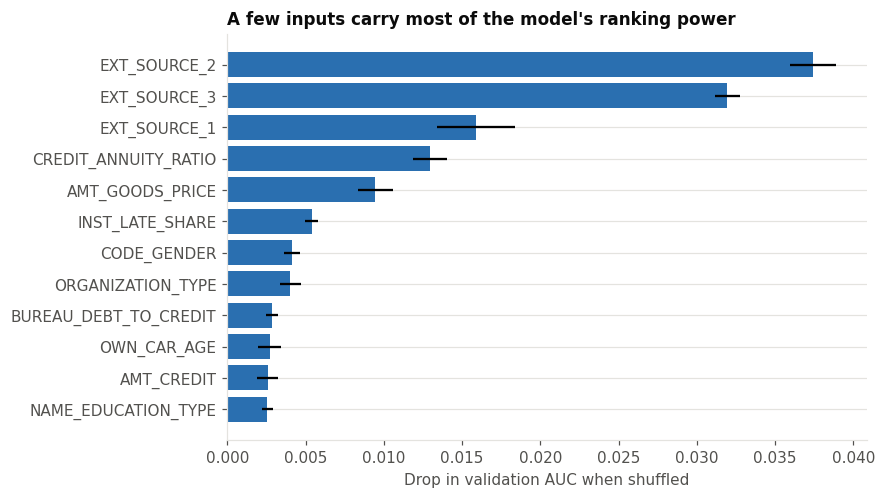

In [4]:
sample = valid.sample(25000, random_state=config.RANDOM_SEED)
importance = global_importance(model, sample, sample[config.TARGET], columns)
print(importance.head(15).round(4).to_string())
top = importance.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.barh(top.index, top["auc_drop"], xerr=top["spread"], color="#2a6fb0")
ax.set_xlabel("Drop in validation AUC when shuffled")
ax.set_title("A few inputs carry most of the model's ranking power", loc="left")
plt.show()
print("columns with importance <= 0.0002:", int((importance["auc_drop"] <= 0.0002).sum()), "of", len(importance))

**Result.** The top three by far are the external scores: `EXT_SOURCE_2` (AUC drop 0.037), `EXT_SOURCE_3` (0.032) and `EXT_SOURCE_1` (0.016). Then `CREDIT_ANNUITY_RATIO` (0.013), `AMT_GOODS_PRICE` (0.0095), `INST_LATE_SHARE` (0.0054, the best history feature), `CODE_GENDER` (0.0041), `ORGANIZATION_TYPE` (0.0040) and `BUREAU_DEBT_TO_CREDIT` (0.0028). 102 of the 142 columns have an importance of 0.0002 or less.

**Interpretation.** A handful of inputs carry the model. The credit/annuity ratio (an implied loan term) ranks above the raw amounts, which supports keeping the engineered ratios (D18). Most columns contribute almost nothing individually; I did not test whether a model on the top ~40 columns would perform equally, so no claim is made about pruning, but it is an obvious simplification to try. Gender sits seventh, which is why D31 matters.

## Explaining single applicants

Two validation applicants: the highest predicted risk and one near the median. For each, the five features whose replacement by the typical value changes the log-odds most. A positive value means the applicant's actual value pushes risk **up** relative to a typical applicant.

In [5]:
train_frame = table[table["split"] == "train"]
reference = reference_row(train_frame, columns)
def explain(row_label, position):
    row = valid.iloc[position]
    effect = local_attribution(model, row, reference, columns, template=train_frame).head(5)
    print(row_label, "predicted PD:", round(row["pd"], 4), " actual outcome:", int(row[config.TARGET]))
    print(pd.DataFrame({"applicant_value": [row[c] for c in effect.index], "typical_value": [reference[c] for c in effect.index], "log_odds_effect": effect.values.round(3)}, index=effect.index).to_string())
    print()
explain("highest-risk applicant", int(np.argmax(valid["pd"].to_numpy())))
explain("median-risk applicant", int(np.argsort(valid["pd"].to_numpy())[len(valid) // 2]))

highest-risk applicant predicted PD: 0.7652  actual outcome: 1
                       applicant_value  typical_value  log_odds_effect
EXT_SOURCE_3                  0.143758       0.535276            1.091
EXT_SOURCE_2                  0.098468       0.565838            0.898
EXT_SOURCE_1                       NaN       0.505300            0.578
PREV_REFUSED_SHARE            0.666667       0.000000            0.475
BUREAU_DEBT_TO_CREDIT         0.645080       0.223225            0.288

median-risk applicant predicted PD: 0.0505  actual outcome: 0
                       applicant_value  typical_value  log_odds_effect
EXT_SOURCE_2                  0.715581       0.565838           -0.384
BUREAU_DEBT_TO_CREDIT         0.754854       0.223225            0.290
DAYS_EMPLOYED            -11692.000000   -1650.000000           -0.288
AMT_GOODS_PRICE          675000.000000  450000.000000           -0.206
INST_LATE_SHARE               0.100000       0.018519            0.200



**Result.** The highest-risk applicant has a predicted PD of 76.5% (and did have the outcome). The reasons: `EXT_SOURCE_3` (0.14 vs typical 0.54, +1.09 log-odds), `EXT_SOURCE_2` (0.10 vs 0.57, +0.90), missing `EXT_SOURCE_1` (+0.58), a previous-application refusal share of 0.67 (+0.48) and a bureau debt-to-credit ratio of 0.65 (+0.29). The median-risk applicant (PD 5.1%) has a mix: a good external score 2 (-0.38) and a long job tenure (-0.29) offset a high bureau debt ratio of 0.75 (+0.29) and a higher late-instalment share of 0.10 (+0.20).

**Interpretation.** These read like an underwriter's reasoning: low outside scores and past refusals raise risk, long employment and a good score lower it. Note that a missing `EXT_SOURCE_1` is itself treated as a risk signal, because missingness was informative in the training data (D10). Occlusion effects are relative to a typical applicant and do not sum to the total, because the model is non-linear.

## Risk bands

Edges at predicted PD of 3%, 6%, 10% and 16%. The top edge is the approval cutoff from Notebook 07; the lower edges split the approved population into roughly equal steps in risk. Bands are judged by whether actual default rates rise from one band to the next.

           applicants   share  mean_pd  actual_default_rate  expected_loss  realised_loss
band                                                                                     
Low             18121  0.2946   0.0188               0.0172   9.897123e+07   9.371762e+07
Moderate        16841  0.2738   0.0433               0.0431   2.029285e+08   2.114335e+08
Elevated        10933  0.1778   0.0773               0.0798   2.221359e+08   2.375277e+08
High             7500  0.1219   0.1258               0.1323   2.348435e+08   2.415713e+08
Very high        8107  0.1318   0.2624               0.2545   4.833672e+08   4.738902e+08


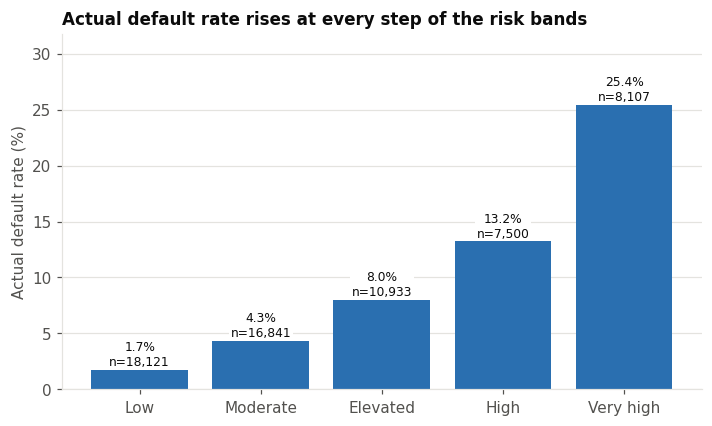

In [6]:
valid["band"] = assign_band(valid["pd"])
summary = band_summary(y, valid["pd"], valid["AMT_CREDIT"])
print(summary.round(4).to_string())
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(summary.index.astype(str), summary["actual_default_rate"] * 100, color="#2a6fb0")
for i, (rate, n) in enumerate(zip(summary["actual_default_rate"], summary["applicants"])):
    ax.text(i, rate * 100 + 0.4, f"{rate*100:.1f}%\nn={n:,}", ha="center", fontsize=8, bbox=dict(facecolor="white", edgecolor="none", pad=1))
ax.set_ylabel("Actual default rate (%)")
ax.set_ylim(0, summary["actual_default_rate"].max() * 100 * 1.25)
ax.set_title("Actual default rate rises at every step of the risk bands", loc="left")
plt.show()

**Result.** Actual default rates rise at every step: Low 1.7% (29.5% of applicants), Moderate 4.3% (27.4%), Elevated 8.0% (17.8%), High 13.2% (12.2%), Very high 25.5% (13.2%). The mean predicted PD is close to the actual rate in each band (for example 26.2% vs 25.5% in Very high).

**Interpretation.** The bands separate risk cleanly: the top band defaults about fifteen times as often as the lowest. The two top bands together hold 25% of applicants but 46% of the expected loss (717 of 1,242 million), which is the practical case for a differentiated policy.

**Decision.** Keep these five bands and edges (3%, 6%, 10%, 16%), documented as project-defined. See D32.

## Expected loss

Expected loss = PD x LGD x EAD, with **LGD = 45%** and **EAD = `AMT_CREDIT`** (project-defined assumptions, D28). The check that matters: does the predicted total match the loss that actually occurred under the same LGD and EAD? Because the label is only 'early payment difficulty', 'realised loss' here means LGD x credit for applicants labelled 1, not an accounting loss.

In [7]:
valid["expected_loss"] = expected_loss(valid["pd"], valid["AMT_CREDIT"])
valid["realised_loss"] = valid[config.TARGET] * ASSUMED_LGD * valid["AMT_CREDIT"]
total_exposure = valid["AMT_CREDIT"].sum()
print("total exposure (millions):", round(total_exposure / 1e6, 1))
print("expected loss (millions): ", round(valid["expected_loss"].sum() / 1e6, 1), " rate:", round(valid["expected_loss"].sum() / total_exposure, 4))
print("realised loss (millions): ", round(valid["realised_loss"].sum() / 1e6, 1), " rate:", round(valid["realised_loss"].sum() / total_exposure, 4))
rng = np.random.default_rng(config.RANDOM_SEED)
ratios = []
for _ in range(300):
    rows = rng.integers(0, len(valid), len(valid))
    part = valid.iloc[rows]
    ratios.append(part["expected_loss"].sum() / part["realised_loss"].sum())
print("expected / realised, 95% interval:", np.round(np.percentile(ratios, [2.5, 97.5]), 3))
print()
print((summary[["expected_loss", "realised_loss"]] / 1e6).round(1).assign(ratio=(summary["expected_loss"] / summary["realised_loss"]).round(3)).to_string())

total exposure (millions): 36820.5
expected loss (millions):  1242.2  rate: 0.0337
realised loss (millions):  1258.1  rate: 0.0342
expected / realised, 95% interval: [0.958 1.019]

           expected_loss  realised_loss  ratio
band                                          
Low                 99.0           93.7  1.056
Moderate           202.9          211.4  0.960
Elevated           222.1          237.5  0.935
High               234.8          241.6  0.972
Very high          483.4          473.9  1.020


**Result.** On 36,820 million of exposure, the model's expected loss is 1,242 million (3.37% of exposure) and the realised loss under the same LGD and EAD is 1,258 million (3.42%). The ratio of expected to realised is 0.99 (0.958 to 1.019 by bootstrap, which includes 1). By band the ratio ranges from 0.935 (Elevated) to 1.056 (Low).

**Interpretation.** In aggregate the expected loss is unbiased. The per-band ratios wander by up to 6.5%, which is the size of ordinary sampling noise for bands of this size. The absolute amount depends completely on the assumed 45% LGD and on treating the credit amount as fully exposed, and 'realised loss' is a hypothetical figure derived from the early-difficulty label. It validates the *calibration* of PD, not the loss amount.

**Decision.** Expected loss per applicant = PD x 45% x AMT_CREDIT, with assumptions exposed as inputs in the app.

In [8]:
importance.to_csv(config.REPORTS_DIR / "permutation_importance.csv")
summary.to_csv(config.REPORTS_DIR / "band_summary.csv")
segments.to_csv(config.REPORTS_DIR / "segment_performance.csv", index=False)
train = table[table["split"] == "train"]
numeric = [c for c in columns if pd.api.types.is_numeric_dtype(train[c])]
profile = {"reference": reference, "numeric_ranges": {c: [float(train[c].quantile(0.01)), float(train[c].quantile(0.99))] for c in numeric},
           "categories": {c: sorted(train[c].dropna().unique().tolist()) for c in columns if c not in numeric}}
joblib.dump(profile, config.MODELS_DIR / "input_profile.joblib")
print("saved reports and input profile")

saved reports and input profile


## Next step

Phase 9: SQL analytics on the scored portfolio, then the Streamlit app and the AI Risk Analyst.